In [23]:

from typing_extensions import IntVar
import numpy as np
import random
import os
import time
import math
import pandas as pd
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import IPython
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

class Process:
  def __init__(self, burst, arrival, priority):
    self.arrival_time = arrival
    self.burst_time = burst
    self.start_time = float('inf')
    self.finish_time = float('inf')
    self.priority = priority
    self.has_started = False
    self.is_over = False
    self.remaining_time = burst
    self.virtual_runtime = 0

  def start(self, tick, run_time):
    self.start_time = tick
    self.has_started = True
    if(self.remaining_time > run_time):
     self.remaining_time = self.remaining_time - run_time
     tick = tick + run_time
     self.virtual_runtime += run_time
    else:
      self.finish_time = tick + self.remaining_time
      tick = tick + self.remaining_time
      self.is_over = True
      self.virtual_runtime += self.remaining_time
      self.remaining_time = 0
    return tick

  def run(self, tick, run_time):
    if(self.remaining_time > run_time):
      self.remaining_time -= run_time
      tick = tick + run_time
      self.virtual_runtime += run_time
    else:
      self.finish_time = tick + self.remaining_time
      tick = tick + self.remaining_time
      self.virtual_runtime += self.remaining_time
      self.is_over = True
      self.remaining_time = 0
    return tick

def workload_gen():
  rng = np.random.default_rng()
  bursts = rng.integers(low = 1, high = 45, size = 10, endpoint = True)
  priorities = rng.integers(low = 1, high = 5, size = 10, endpoint = True)
  arrivals = np.sort(np.random.randint(0, 101, size = 10))
  processes = [Process(bursts[i], arrivals[i], priorities[i]) for i in range(10)]
  return processes

def calc_metrics(processes):
  wait_times = [p.finish_time - p.arrival_time - p.virtual_runtime for p in processes]
  resp_times = [p.start_time - p.arrival_time for p in processes]
  turnaround_times = [p.finish_time - p.arrival_time for p in processes]
  JFI = jains_fairness(wait_times)
  mean_wait = np.mean(wait_times) if len(wait_times) > 0 else 0.0
  mean_turnaround = np.mean(turnaround_times) if len(turnaround_times) > 0 else 0.0
  mean_resp = np.mean(resp_times) if len(resp_times) > 0 else 0.0
  P90_wait = np.percentile(wait_times, 90) if len(wait_times) > 0 else 0.0
  return mean_turnaround, mean_wait, P90_wait, JFI, mean_resp



def jains_fairness(wait_times_array):
    wait_times_array = np.array(wait_times_array)
    n = len(wait_times_array)
    if n == 0 or np.sum(wait_times_array ** 2) == 0:
        return 1.0
    return (np.sum(wait_times_array) ** 2) / (n * np.sum(wait_times_array ** 2))


Training on device: cuda


In [24]:
def FCFS(workload):
  tick = 0
  wait_times = np.zeros(10)
  turnaround_times = np.zeros(10)
  resp_times = np.zeros(10)
  for i in range(10):
    workload[i].start_time = max(workload[i].arrival_time, tick)
    tick = workload[i].start_time + workload[i].burst_time
    workload[i].finish_time = tick
    workload[i].is_over = True
    workload[i].remaining_time = 0
    turnaround_times[i] = workload[i].finish_time - workload[i].arrival_time
    resp_times[i] = workload[i].start_time - workload[i].arrival_time
    if(i>0):
      wait_times[i] = workload[i].start_time - workload[i].arrival_time

  mean_wait = np.mean(wait_times)
  wait_times.sort()
  P90_wait = wait_times[8]
  mean_turnaround = np.mean(turnaround_times)
  mean_resp_time = np.mean(resp_times)
  return (mean_wait, P90_wait, mean_turnaround, jains_fairness(wait_times), mean_resp_time)

def SJF(workload):
  tick = 0
  wait_times = np.zeros(0)
  turnaround_times = np.zeros(0)
  resp_times = np.zeros(0)
  tick = workload[0].arrival_time
  rem_pro = workload[:]
  while rem_pro:
    queue = [p for p in rem_pro if p.arrival_time <= tick]
    if(not queue):
      tick = min(p.arrival_time for p in rem_pro)
      queue = [p for p in rem_pro if p.arrival_time <= tick]

    b = min(p.burst_time for p in queue)
    to_be_run = [p for p in queue if p.burst_time <= b]
    for p in to_be_run:
      p.is_over = True
      p.remaining_time = 0
      p.start_time = tick
      tick = tick + b
      p.finish_time = tick
      wait_times = np.append(wait_times, p.start_time - p.arrival_time)
      turnaround_times = np.append(turnaround_times, p.finish_time - p.arrival_time)
      resp_times = np.append(resp_times, p.start_time - p.arrival_time)

    rem_pro = [p for p in rem_pro if p not in to_be_run]


  mean_wait = np.mean(wait_times) if len(wait_times) > 0 else 0.0
  wait_times.sort()
  P90_wait = wait_times[8]
  mean_turnaround = np.mean(turnaround_times)
  mean_resp_time = np.mean(resp_times)
  return (mean_wait, P90_wait, mean_turnaround, jains_fairness(wait_times), mean_resp_time)


def RR(workload, q):
   tick = workload[0].arrival_time
   rem_pro = workload[:]
   wait_times = np.zeros(0)
   turnaround_times = np.zeros(0)
   resp_times = np.zeros(0)
   over = []
   while rem_pro:
    for p in rem_pro:
      if(p.is_over == True):
        over.append(p)
        wait_times =  np.append(wait_times, p.finish_time - p.arrival_time - p.burst_time)
        turnaround_times = np.append(turnaround_times, p.finish_time - p.arrival_time)
        resp_times = np.append(resp_times, p.start_time - p.arrival_time)
      else:
        if(p.arrival_time <= tick):
          if(p.has_started == True):
            tick = p.run(tick, q)
          else:
            tick = p.start(tick, q)

      queue = [p for p in rem_pro if p.arrival_time <= tick]
      if not queue:
        tick = min(p.arrival_time for p in rem_pro)

    rem_pro = [p for p in rem_pro if p not in over]

   mean_wait = np.mean(wait_times)
   wait_times.sort()
   P90_wait = np.percentile(wait_times, 90)
   mean_turnaround = np.mean(turnaround_times)
   mean_resp_time = np.mean(resp_times)
   return (mean_wait, P90_wait, mean_turnaround, jains_fairness(wait_times), mean_resp_time)


def var(data):
  mew = np.mean(data)
  vari = 0
  for x in data:
    vari += (x-mew)**2
  vari = vari/len(data)
  return vari





In [ ]:
class SchedulingEnv:
    def __init__(self, q=4):
        self.q = q
        self.curr_tick = 0
        self.state_tensor = None
        self.curr_queue = None
        self.state_mask = None
        self.workload = None
        self.completed_pro = []

    def get_state_tensor(self, processes, tick):
       queue = [p for p in processes if p.arrival_time <= tick and p.is_over == False]
       self.completed_pro = [p for p in self.workload if p.is_over == True]
       if not queue:
        completed = [p for p in self.workload if p.is_over == True]
        if(len(completed) == len(self.workload)):
          return torch.zeros(10, 3), torch.zeros(10, dtype = torch.bool), True
        else:
          tick = min(p.arrival_time for p in processes)
          self.curr_tick = tick
          queue = [p for p in processes if p.arrival_time <= tick and p.is_over == False]
       max_rem = max((p.remaining_time for p in queue), default = 0)
       max_wait = max((tick - p.arrival_time - p.virtual_runtime for p in queue), default = 0)
       max_priority = max((p.priority for p in queue), default = 1)
       self.curr_queue = queue


       st_tensor = torch.zeros(10, 3)
       i = 0
       for p in queue:
        st_tensor[i][0] = p.remaining_time/max(max_rem, 1)
        st_tensor[i][1] = (tick - p.arrival_time - p.virtual_runtime)/max(max_wait, 1)
        st_tensor[i][2] = p.priority/max_priority
        i += 1

       mask = torch.zeros(10, dtype=torch.bool)
       mask[:len(queue)] = True
       self.state_tensor = st_tensor
       self.state_mask = mask
       return st_tensor, mask, False


    def reset(self):
      self.workload = workload_gen()
      self.curr_tick = 0
      return self.get_state_tensor(self.workload, self.curr_tick)

    def reward(self):
      if not self.curr_queue:
        return 0.0

      virtual_runtimes = [p.virtual_runtime for p in self.curr_queue]
      v_bar = np.mean(virtual_runtimes) if len(virtual_runtimes)>0 else 0.0
      var = 0
      l = len(self.curr_queue)
      reward = 60 - 2*l
      for v in virtual_runtimes:
        var += (v-v_bar)**2
      var = var/max(1, len(virtual_runtimes))
      SD = np.sqrt(var)
      if(SD/max(np.mean(virtual_runtimes), 1) > 0.3):
        reward = reward - 70*SD/max(1, np.mean(virtual_runtimes))
      else:
        reward = reward + 30 - 50*SD/max(1, np.mean(virtual_runtimes))


      wait_times = [(self.curr_tick - p.arrival_time - p.virtual_runtime) for p in self.curr_queue]
      reward -= 0.5 * np.mean(wait_times) if len(wait_times) > 0 else 0.0


      resp_times = [p.start_time - p.arrival_time for p in self.curr_queue if p.has_started == True]
      r = np.mean(resp_times) if len(resp_times) > 0 else 0.0
      if(r <= 8):
        reward = reward - 4*r + 10
      else:
        reward = reward - 6*r
      return reward

    def step(self, action):
        if action >= len(self.curr_queue) or not self.state_mask[action]:
            self.curr_tick += 1
            next_st, next_mask, done = self.get_state_tensor(self.workload, self.curr_tick)
            return next_st, next_mask, -50.0, done

        proc = self.curr_queue[action]
        if proc.has_started:
            self.curr_tick = proc.run(self.curr_tick, 1)
        else:
            self.curr_tick = proc.start(self.curr_tick, 1)

        next_st, next_mask, done = self.get_state_tensor(self.workload, self.curr_tick)
        rew = self.reward()
        return next_st, next_mask, rew, done





test_env = SchedulingEnv()
test_env.reset()

class DirectSchedulerNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.embedding = nn.Linear(3, 64)
    self.position = nn.Parameter(torch.randn(10,64))
    self.attention = nn.MultiheadAttention(embed_dim = 64, num_heads = 4, batch_first = True)
    self.head = nn.Sequential(nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))


  def forward(self, x, mask):
    x = self.embedding(x)
    x = x + self.position
    x, _ = self.attention(x, x, x, key_padding_mask = ~mask)
    q = self.head(x)
    q = q.squeeze(-1)
    q = q.masked_fill(~mask, float("-inf"))
    return q

scheduler = DirectSchedulerNet()
q = scheduler(torch.from_numpy(np.zeros((10, 3))).float(), torch.zeros(10, dtype = torch.bool))

print(q, q.shape)



class Replay_Buffer():
  def __init__(self, capacity = 5000):
    self.capacity = capacity
    self.experiences = []

  def add(self, state, state_mask, action, reward, next_state, next_state_mask, done):
    self.experiences.append((state, state_mask, action, reward, next_state, next_state_mask, done))
    return

  def __len__(self):
    return len(self.experiences)

  def sample(self, batch_size = 64):
    return random.sample(self.experiences, batch_size)


def moving_average(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode="valid")


class DQN_agent():
  def __init__(self, epsilon = 1.0, eta = 0.9995, alpha = 5e-3, gamma = 0.99, eps_min = 1e-4):
    self.policy_net = DirectSchedulerNet()
    self.target_net = DirectSchedulerNet()
    self.target_net.load_state_dict(self.policy_net.state_dict())
    self.epsilon = epsilon
    self.eta = eta
    self.alpha = alpha
    self.gamma = gamma
    self.eps_min = eps_min
    self.optimizer = torch.optim.Adam(self.policy_net.parameters(), lr = alpha)
    self.rb = Replay_Buffer()

  def select_action(self, state, st_mask):
    if np.random.random() < self.epsilon:
      valid_actions = torch.where(mask.squeeze() == True)[0].tolist()
      if len(valid_actions) > 0:
            return random.choice(valid_actions)
      else:
            return 0

    with torch.no_grad():
      best_action = int(torch.argmax(self.policy_net(state, st_mask)).item())

    return best_action

  def decay_epsilon(self):
        if(self.epsilon > self.eps_min):
          self.epsilon = self.eta*self.epsilon
        else:
          self.epsilon = self.eps_min


env = SchedulingEnv()
agent = DQN_agent()
agent.policy_net.to(device)
agent.target_net.to(device)
waits = []
p90_waits = []
resp_times = []
jfis  = []
turnarounds = []
q_log = []
q_means = []
ep_rewards = []
loss_tot = 0



for episode in range(30000):
    state, mask, done = env.reset()
    state = state.to(device)
    mask = mask.to(device)
    ep_rew = 0
    q_log = []


    while not done:
        q_values = agent.policy_net(state, mask)
        action = agent.select_action(state, mask)
        q_log.append(q_values[mask].mean().item())
        next_state, next_mask, reward, done = env.step(action)
        next_state = next_state.to(device)
        next_mask = next_mask.to(device)
        ep_rew += reward
        agent.rb.add(state, mask, action, reward, next_state, next_mask, done)
        if(len(agent.rb) >= 64):
          batch = agent.rb.sample()
          states, st_masks, actions, rewards, next_states, next_masks, dones = zip(*batch)
          states_t = torch.stack(states).to(device)
          st_masks_t = torch.stack(st_masks).to(device)
          actions_t = torch.tensor(actions, dtype=torch.int).unsqueeze(1).to(device)
          rewards_t = torch.tensor(rewards, dtype=torch.float).unsqueeze(1).to(device)
          next_states_t = torch.stack(next_states).to(device)
          next_masks_t = torch.stack(next_masks).to(device)
          dones_t = torch.tensor(dones, dtype=torch.float).unsqueeze(1).to(device)
          curr_q_vals = agent.policy_net(states_t, st_masks_t).gather(1, actions_t).to(device)
          with torch.no_grad():
            next_actions =  agent.policy_net(next_states_t, next_masks_t).max(1)[1].unsqueeze(1)

            q_targets = agent.target_net(next_states_t, next_masks_t).gather(1, next_actions)
            td_targets = rewards_t + agent.gamma*q_targets*(1 - dones_t)

          loss = F.mse_loss(td_targets, curr_q_vals)
          agent.optimizer.zero_grad()
          loss.backward()
          agent.optimizer.step()
          loss_tot += loss.item()


        if len(q_log) > 0:
          q_means.append(np.mean(q_log))
        else:
          q_means.append(0.0)
        state, mask = next_state, next_mask

    agent.decay_epsilon()
    ep_rewards.append(ep_rew)
    x1, x2, x3, x4, x5 = calc_metrics(env.completed_pro)
    turnarounds.append(x1)
    waits.append(x2)
    p90_waits.append(x3)
    jfis.append(x4)
    resp_times.append(x5)


    if (episode + 1) % 100 == 0:

       recent_avg_reward = np.mean(ep_rewards[-100:])

       print(f"Episode {episode + 1} completed | Latest Reward: {ep_rew:.2f} | 100-Ep Avg Reward: {recent_avg_reward:.2f}")


    if(episode % 500 == 0):
      agent.target_net.load_state_dict(agent.policy_net.state_dict())


























tensor([-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
       grad_fn=<MaskedFillBackward0>) torch.Size([10])


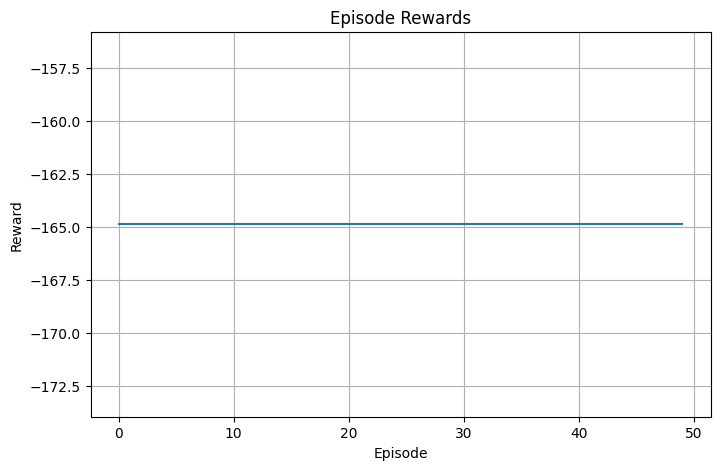

In [29]:
plt.figure(figsize=(8,5))
plt.plot(moving_average(ep_rewards, 50))
plt.title("Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid()
plt.show()

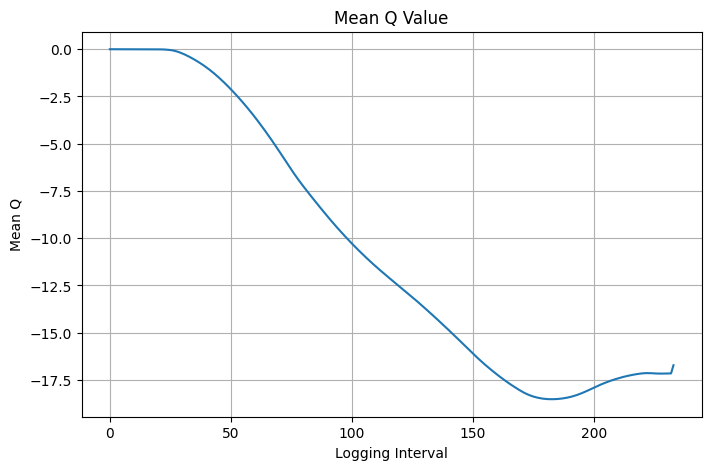

In [30]:
plt.figure(figsize=(8,5))
plt.plot(moving_average(q_means, 50))
plt.title("Mean Q Value")
plt.xlabel("Logging Interval")
plt.ylabel("Mean Q")
plt.grid()
plt.show()

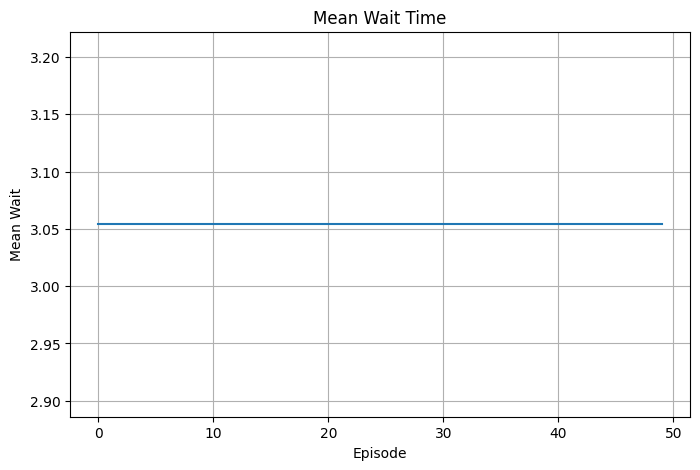

In [31]:
plt.figure(figsize=(8,5))
plt.plot(moving_average(waits, 50))
plt.title("Mean Wait Time")
plt.xlabel("Episode")
plt.ylabel("Mean Wait")
plt.grid()
plt.show()

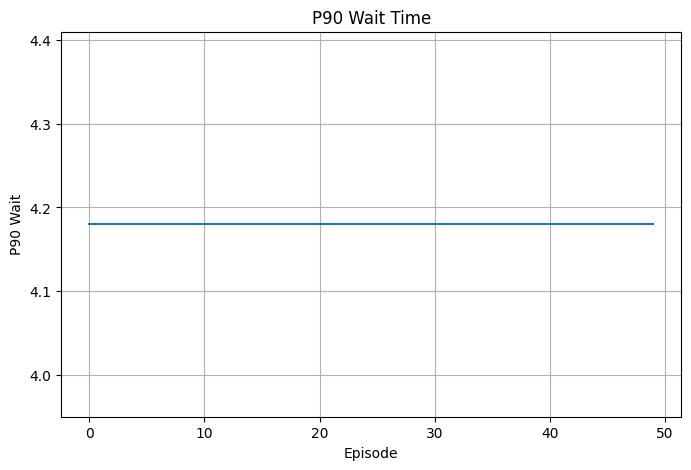

In [32]:
plt.figure(figsize=(8,5))
plt.plot(moving_average(p90_waits, 50))
plt.title("P90 Wait Time")
plt.xlabel("Episode")
plt.ylabel("P90 Wait")
plt.grid()
plt.show()


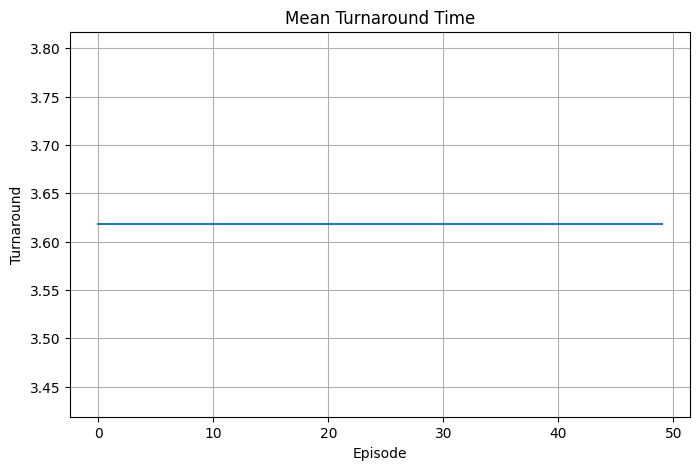

In [33]:
plt.figure(figsize=(8,5))
plt.plot(moving_average(turnarounds, 50))
plt.title("Mean Turnaround Time")
plt.xlabel("Episode")
plt.ylabel("Turnaround")
plt.grid()
plt.show()

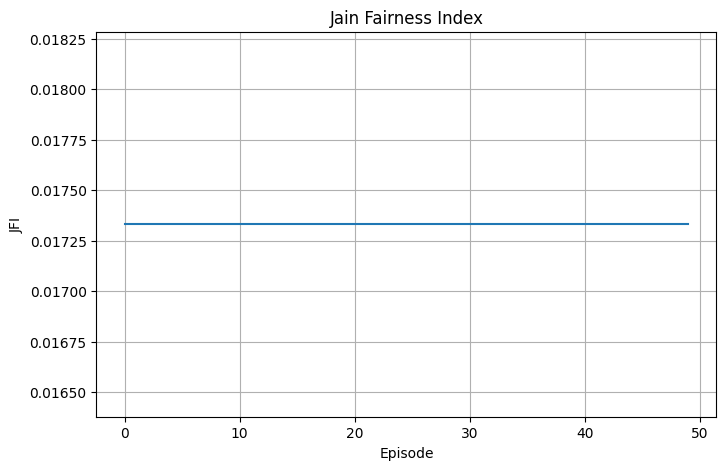

In [34]:
plt.figure(figsize=(8,5))
plt.plot(moving_average(jfis, 50))
plt.title("Jain Fairness Index")
plt.xlabel("Episode")
plt.ylabel("JFI")
plt.grid()
plt.show()
